# Triaging of datasets

In [ ]:
import pandas as pd
import numpy as np
import scipy
from scipy import stats

from numba import njit

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors
import regseq2 

from glob import glob

regseq2.viz.matplotlib_style()
my_color_dict = regseq2.viz.my_color_dict

Loading BokehJS ...

## Import growth conditions

In [2]:
df_gc = pd.read_csv("../../data/metadata/growth_conditions_short.csv", delimiter=";")
df_gc.head(5)

,Index,Condition,Description,Group
0,1,glucose,M9 Minimal Media with 0.5% Glucose,Carbon‐source
1,2,xylose,M9 Minimal Media with 0.5% Xylose,Carbon‐source
2,3,arabinose,M9 Minimal Media with 0.5% Arabinose,Carbon‐source
3,4,galactose,M9 Minimal Media with 0.23% Galactose,Carbon‐source
4,5,sodium salicytate,M9 Minimal Media with 0.5% Glucose and 2.5mM S...,Small-molecule inducers


## Function to smooth data for given width of smoothing kernel

In [5]:

def smooth_data(sigma=2):
    prom_list = []
    gc_list = []
    rep_list = []
    cv_list = []
    cv_smooth_list = []
    ent_list = []
    ent_smoothed_list = []
    
    for file in files:
        # import file
        df = pd.read_csv(file)
        # get growth condition and replicate from file name
        gc = file.split('/')[-1].split('-')[0]
        rep = file.split('/')[-1].split('-')[1][0]
    
        # iterate through promoters
        for prom, gdf in df.groupby("promoter"):
            if prom not in ["galEp", "ybeDp2"]:
                # get MI
                x = np.array(gdf['mut_info'].values)
                # compute coefficient of variation
                cv = np.std(x)/np.mean(x)
                cv_list.append(cv)
                # normalize and compute entropy
                temp_x = x / np.sum(x)
                ent_list.append(np.sum(-temp_x * np.log2(temp_x)))
    
                # smooth footprint and recompute
                x = scipy.ndimage.gaussian_filter1d(x, sigma)
                cv = np.std(x)/np.mean(x)
                cv_smooth_list.append(cv)
                temp_x = x / np.sum(x)
                ent_smoothed_list.append(np.sum(-temp_x * np.log2(temp_x)))
    
                # append metadata
                prom_list.append(prom)
                gc_list.append(gc)
                rep_list.append(rep)
    
    df_out = pd.DataFrame(
        dict(
            promoter=prom_list, 
            gc=gc_list, 
            rep=rep_list, 
            cv=cv_list,
            cv_smooth=cv_smooth_list,
            entropy=ent_list, 
            entropy_smooth=ent_smoothed_list,
        )).sort_values("cv", ascending=False).reset_index(drop=True)
    
    
    df_out.head()
    return df_out

In [ ]:
files = glob("../../data/footprints/*")
df_out = smooth_data(2)

We want to create example footprints that contain a certain number of positions with high mutual information. To do that, we create some gaussian noise and add a large signal in the middle of the footprint.

In [ ]:
x = np.abs(np.random.randn(160)/10000)
j=1
r=0.001
#x[np.arange(0, 160, step=160/j, dtype=int)] = r
x[100-j:100] = r

fig, ax = plt.subplots(figsize=(2,1))
ax.bar(np.arange(-115, 45), x)

j=1
r=0.01
#x[np.arange(0, 160, step=160/j, dtype=int)] = r
x[100-j:100] = r

fig, ax = plt.subplots(figsize=(2,1))
ax.bar(np.arange(-115, 45), x)

## Iterate through different smoothing widths

Now we are trying out different widths of the gaussian kernel for signals if varying widths, and check out the smoothing affects the observed coefficient of variation across the information footprint.

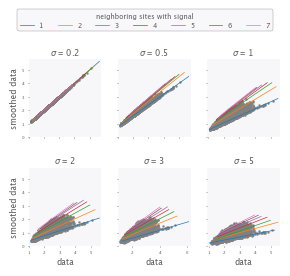

In [ ]:
regseq2.viz.paper_params()
fig, ax_list = plt.subplots(2, 3, figsize=(3, 2.5), sharey=True)
for sigma, ax in zip([0.2, 0.5, 1, 2, 3, 5], np.ravel(ax_list)):
    df_out = smooth_data(sigma)
    # downsample data points to make file size smaller
    x1 = df_out.loc[df_out['cv'] > 2, 'cv'].values
    y1 = df_out.loc[df_out['cv'] > 2, 'cv_smooth'].values
    ax.scatter(x1, y1, s=2, color="gray")
    
    x2 = df_out.loc[df_out['cv'] < 2, 'cv'].values
    y2 = df_out.loc[df_out['cv'] < 2, 'cv_smooth'].values
    inds = np.random.choice(np.arange(len(x2)), 1000)
    ax.scatter(x2[inds], y2[inds], s=2, color="gray")
    
    
    for j in range(1, 8):
        x = np.abs(np.random.randn(160)/10000)
        arr = []
        arr_s = []
        for r in np.arange(0.001, 0.01, step=0.0001):
            #x[np.arange(0, 160, step=160/j, dtype=int)] = r
            x[100-j:100] = r
            arr.append(np.std(x)/np.mean(x))
            _x = scipy.ndimage.gaussian_filter1d(x, sigma)
            arr_s.append(np.std(_x)/np.mean(_x))
        ax.plot(arr, arr_s, linewidth=0.5, label=j)
    
    ax.set_title(r"$\sigma$ = {}".format(sigma))
    ax.set_xlabel('data')
    ax.set_ylabel('smoothed data')
    ax.label_outer()
    ax.grid(True)
    

handles, labels = ax_list[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', title="neighboring sites with signal", ncols=7, bbox_to_anchor=(0.5, 1.1, 0, 0))
plt.tight_layout()
#fig.savefig("files/cv_cv-smoothed_changing_sigma.pdf", bbox_inches='tight')
    

We can use this to create classes for footprints, where we identify promoters where a single mutation carries most of the signal, which is an indication of a de novo promoter.

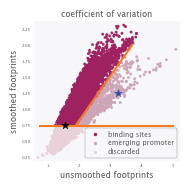

In [ ]:
# Define ranges for classes
x = [1.9, 3.7]
y = [0.75, 2]

# choose kernel width and smooth data
sigma = 2
df_out = smooth_data(sigma)

# choose noise floor (computed below)
thresh = 0.75

# draw threshold lines
thresh_function = lambda t: ((y[1] - y[0]) / (x[1] - x[0])) * (t - x[0]) + y[0]

# classify footrpints
inds_footprints = (df_out.cv_smooth.values > thresh) & (df_out.cv_smooth.values > thresh_function(df_out.cv.values))
inds_single_peaks = (df_out.cv_smooth.values > thresh) & (df_out.cv_smooth.values < thresh_function(df_out.cv.values))
inds_out = (df_out.cv_smooth.values < thresh)

# visualize the results

# define arrays for classes and colors
colors = np.empty(len(df_out.entropy.values), dtype='object')
classification = np.empty(len(df_out.entropy.values), dtype='object')

# assign colors and classes
colors[inds_footprints] = my_color_dict["purple1"]
classification[inds_footprints] = 2

colors[inds_single_peaks] = my_color_dict["purple2"]
classification[inds_single_peaks] = 1

colors[inds_out] = my_color_dict["purple3"]
classification[inds_out] = 0


# plot the results
fig, ax = plt.subplots(figsize=(2, 2))

ax.scatter(df_out.cv.values, df_out.cv_smooth.values, s=3, color=colors)

# draw threshold lines
ax.plot([thresh, 5], [thresh, thresh], linewidth=1.5, color=my_color_dict['orange1'])
ax.plot(x,y, linewidth=1.5, color=my_color_dict['orange1'])


# highlight araB promoter, which is expressing in one condition and has a de novo promoter in another
x1 = df_out[(df_out['promoter'] == "araBp") & (df_out['gc'] == "3") & (df_out['rep'] == "1")]['cv'].values[0]
y1 = df_out[(df_out['promoter'] == "araBp") & (df_out['gc'] == "3") & (df_out['rep'] == "1")]['cv_smooth'].values[0]
x2 = df_out[(df_out['promoter'] == "araBp") & (df_out['gc'] == "2") & (df_out['rep'] == "1")]['cv'].values[0]
y2 = df_out[(df_out['promoter'] == "araBp") & (df_out['gc'] == "2") & (df_out['rep'] == "1")]['cv_smooth'].values[0]

ax.scatter([x1], [y1], marker="*", color="black", zorder=2)
ax.scatter([x2], [y2], marker="*", color=my_color_dict['blue1'], zorder=2)

# make legends
legend_elements = [Line2D([0], [0], marker='o', color='w', label='binding sites',
                          markerfacecolor=my_color_dict["purple1"], markersize=3),
                  Line2D([0], [0], marker='o', color='w', label='emerging promoter',
                          markerfacecolor=my_color_dict["purple2"], markersize=3),
                   Line2D([0], [0], marker='o', color='w', label='discarded',
                          markerfacecolor=my_color_dict["purple3"], markersize=3)
                  ]
ax.legend(handles=legend_elements, loc='lower right', fontsize=5)

ax.set_xlabel('unsmoothed footprints', fontsize=6)
ax.set_xlabel('unsmoothed footprints', fontsize=6)
ax.set_ylabel('smoothed footprints', fontsize=6)
ax.set_title("coefficient of variation", fontsize=6)
ax.tick_params(axis='both', labelsize=3)
plt.tight_layout()
#fig.savefig("smoothing_classes.pdf")

Save the results.

In [ ]:
df_out['classification'] = classification
#df_out.to_csv('triaging.csv', index=False)

## Shuffling

To estimate the noise floor, we *shuffle* the data, which means we randomly reassign a barcode to a to how many reads it got. This will scramble the correlation between mutations in the promoter sequence and the observed expression. By doing this many times, we can estimate what the coefficient of variation of a random dataset would be, and use this as a cutoff for our data.

First get the file names. 

In [33]:
files = glob('footprints/*')
inds = [x.split('/')[1].split('_')[0] for x in files]

In [ ]:
df_map = pd.read_csv("../../data/mapping/mapped_barcodes_filtered.csv")

FileNotFoundError: [Errno 2] No such file or directory: '../../data/mapping/mapped_barcodes_filtered.csv'

In [35]:
df_wt = pd.read_csv("../../data/metadata/wt_sequences.csv")[['promoter_seq', 'promoter']]
wt_dict = dict(zip(df_wt['promoter'].values, df_wt['promoter_seq'].values))
df_wt

,promoter_seq,promoter
0,TTTCATCTTTTGTCAACCATTCACAGCGCAAATATACGCCTTTTTT...,rspAp
1,TCCACATTGATTATTTGCACGGCGTCACACTTTGCTATGCCATAGC...,araBp
2,GTGTTGCACCTCCCCAGAGAGCGGCGGATAATGCTGCGAAAAGAAG...,znuCp
3,CCAGTTTCATCATTCCATTTTATTTTGCGAGCGAGCGCACACTTGT...,xylAp
4,AATTGCGCAACAAAAGTAAGATCTCGGTCATAAATCAAGAAATAAA...,xylFp
...,...,...
114,TGGTGCTGGTTATCAGCACTGAAGGCGACACCGACGTGAAGCACTA...,ygeY_predicted
115,CGCTGGACGAAATCCGCGCCCTGCCTGCAGTACAGAAAGCTAACGC...,hyuA_predicted
116,TCGGACATGTTTGAAGAGATGAAATTTGCCTTCTTTAAACATCGCG...,ygfM_xdhD_predicted
117,AGTGCCAGTTTTTGCGAGGAAGGGGAGTTAGAGACAGGAATTGCGG...,ygfS_ygfT_predicted


In [38]:
@njit
def compare_string_bytes(s1, s2):
    # Ensure both strings are of equal length.
    n = len(s1)
    if n != len(s2):
        raise ValueError("Strings must have the same length")
    result = np.empty(n, dtype=np.int64)
    for i in range(n):
        result[i] = 1 if s1[i] == s2[i] else 0
    return result


def clog(x, y, z):
    if x == 0 or y == 0 or z==0:
        return 0
    else:
        return x * np.log2(x / (y * z))

cv_list = []
cv_list_smooth = []
for ind in inds:
    file_DNA = glob(f"../../../Reg-Seq-2/data/barcode_counts/*/{ind}*DNA*.txt")[0]
    df_DNA = pd.read_csv(
        file_DNA, 
        names=['ct_0', 'barcode'], sep="\\s+")
    file_RNA = glob(f"../../../Reg-Seq-2/data/barcode_counts/*/{ind}*RNA*.txt")[0]
    df_RNA = pd.read_csv(
        file_RNA, 
        names=['ct_1', 'barcode'], sep="\\s+")
    
    df_counts = df_DNA.merge(df_RNA, on="barcode", how='outer').fillna(0)
    df_counts = df_counts.merge(df_map, on="barcode", how='inner')
    
    df_counts.head()
    
    df_out = pd.DataFrame()
    for promoter, gdf in df_counts.groupby('promoter'):
    
        # find where the mutations are
        wt_seq = wt_dict[promoter]
        is_wt = np.vstack([np.array(compare_string_bytes(wt_seq.encode("ascii"), x.encode("ascii"))) for x in gdf['promoter_variant'].values])
        
        # compute relative counts
        p = np.zeros([160, 2, 2])
        for i in range(100):
            indexes = np.random.permutation(len(gdf['ct_0'].values))
            p [:, :, 0] = np.matmul(is_wt.T, np.vstack([gdf['ct_0'].values[indexes], gdf['ct_1'].values[indexes]]).T)
            p [:, :, 1] = np.matmul((1-is_wt).T, np.vstack([gdf['ct_0'].values[indexes], gdf['ct_1'].values[indexes]]).T)
            p = p / (np.sum(gdf['ct_0'].values[indexes]) + np.sum(gdf['ct_1'].values[indexes]))
        
            mut_info = [sum([clog(p[i, j, k], np.sum(p[i, :, k]), np.sum(p[i, j, :])) for j in range(2) for k in range(2)]) for i in range(160)]
            scipy.ndimage.gaussian_filter1d(x, sigma)
            cv_list.append(np.std(mut_info) / np.mean(mut_info))
            cv_list_smooth.append(np.std(scipy.ndimage.gaussian_filter1d(mut_info, 2)) / np.mean(scipy.ndimage.gaussian_filter1d(mut_info, 2)))
    
    print(f"{ind} done")

/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:53: RuntimeWarning: invalid value encountered in scalar divide
  cv_list.append(np.std(mut_info) / np.mean(mut_info))
/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:54: RuntimeWarning: invalid value encountered in scalar divide
  cv_list_smooth.append(np.std(scipy.ndimage.gaussian_filter1d(mut_info, 2)) / np.mean(scipy.ndimage.gaussian_filter1d(mut_info, 2)))


30-1 done


/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:53: RuntimeWarning: invalid value encountered in scalar divide
  cv_list.append(np.std(mut_info) / np.mean(mut_info))
/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:54: RuntimeWarning: invalid value encountered in scalar divide
  cv_list_smooth.append(np.std(scipy.ndimage.gaussian_filter1d(mut_info, 2)) / np.mean(scipy.ndimage.gaussian_filter1d(mut_info, 2)))


31-2 done


/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:53: RuntimeWarning: invalid value encountered in scalar divide
  cv_list.append(np.std(mut_info) / np.mean(mut_info))
/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:54: RuntimeWarning: invalid value encountered in scalar divide
  cv_list_smooth.append(np.std(scipy.ndimage.gaussian_filter1d(mut_info, 2)) / np.mean(scipy.ndimage.gaussian_filter1d(mut_info, 2)))


10-2 done


/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:53: RuntimeWarning: invalid value encountered in scalar divide
  cv_list.append(np.std(mut_info) / np.mean(mut_info))
/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:54: RuntimeWarning: invalid value encountered in scalar divide
  cv_list_smooth.append(np.std(scipy.ndimage.gaussian_filter1d(mut_info, 2)) / np.mean(scipy.ndimage.gaussian_filter1d(mut_info, 2)))


14-3 done


/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:53: RuntimeWarning: invalid value encountered in scalar divide
  cv_list.append(np.std(mut_info) / np.mean(mut_info))
/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:54: RuntimeWarning: invalid value encountered in scalar divide
  cv_list_smooth.append(np.std(scipy.ndimage.gaussian_filter1d(mut_info, 2)) / np.mean(scipy.ndimage.gaussian_filter1d(mut_info, 2)))


11-1 done


/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:53: RuntimeWarning: invalid value encountered in scalar divide
  cv_list.append(np.std(mut_info) / np.mean(mut_info))
/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:54: RuntimeWarning: invalid value encountered in scalar divide
  cv_list_smooth.append(np.std(scipy.ndimage.gaussian_filter1d(mut_info, 2)) / np.mean(scipy.ndimage.gaussian_filter1d(mut_info, 2)))


4-2 done


/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:53: RuntimeWarning: invalid value encountered in scalar divide
  cv_list.append(np.std(mut_info) / np.mean(mut_info))
/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:54: RuntimeWarning: invalid value encountered in scalar divide
  cv_list_smooth.append(np.std(scipy.ndimage.gaussian_filter1d(mut_info, 2)) / np.mean(scipy.ndimage.gaussian_filter1d(mut_info, 2)))


5-1 done


/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:53: RuntimeWarning: invalid value encountered in scalar divide
  cv_list.append(np.std(mut_info) / np.mean(mut_info))
/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:54: RuntimeWarning: invalid value encountered in scalar divide
  cv_list_smooth.append(np.std(scipy.ndimage.gaussian_filter1d(mut_info, 2)) / np.mean(scipy.ndimage.gaussian_filter1d(mut_info, 2)))


41-1 done


/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:53: RuntimeWarning: invalid value encountered in scalar divide
  cv_list.append(np.std(mut_info) / np.mean(mut_info))
/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:54: RuntimeWarning: invalid value encountered in scalar divide
  cv_list_smooth.append(np.std(scipy.ndimage.gaussian_filter1d(mut_info, 2)) / np.mean(scipy.ndimage.gaussian_filter1d(mut_info, 2)))


40-2 done


/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:53: RuntimeWarning: invalid value encountered in scalar divide
  cv_list.append(np.std(mut_info) / np.mean(mut_info))
/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:54: RuntimeWarning: invalid value encountered in scalar divide
  cv_list_smooth.append(np.std(scipy.ndimage.gaussian_filter1d(mut_info, 2)) / np.mean(scipy.ndimage.gaussian_filter1d(mut_info, 2)))


25-2 done


/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:53: RuntimeWarning: invalid value encountered in scalar divide
  cv_list.append(np.std(mut_info) / np.mean(mut_info))
/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:54: RuntimeWarning: invalid value encountered in scalar divide
  cv_list_smooth.append(np.std(scipy.ndimage.gaussian_filter1d(mut_info, 2)) / np.mean(scipy.ndimage.gaussian_filter1d(mut_info, 2)))


24-1 done


/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:53: RuntimeWarning: invalid value encountered in scalar divide
  cv_list.append(np.std(mut_info) / np.mean(mut_info))
/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:54: RuntimeWarning: invalid value encountered in scalar divide
  cv_list_smooth.append(np.std(scipy.ndimage.gaussian_filter1d(mut_info, 2)) / np.mean(scipy.ndimage.gaussian_filter1d(mut_info, 2)))


40-3 done


/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:53: RuntimeWarning: invalid value encountered in scalar divide
  cv_list.append(np.std(mut_info) / np.mean(mut_info))
/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:54: RuntimeWarning: invalid value encountered in scalar divide
  cv_list_smooth.append(np.std(scipy.ndimage.gaussian_filter1d(mut_info, 2)) / np.mean(scipy.ndimage.gaussian_filter1d(mut_info, 2)))


20-1 done


/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:53: RuntimeWarning: invalid value encountered in scalar divide
  cv_list.append(np.std(mut_info) / np.mean(mut_info))
/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:54: RuntimeWarning: invalid value encountered in scalar divide
  cv_list_smooth.append(np.std(scipy.ndimage.gaussian_filter1d(mut_info, 2)) / np.mean(scipy.ndimage.gaussian_filter1d(mut_info, 2)))


25-3 done


/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:53: RuntimeWarning: invalid value encountered in scalar divide
  cv_list.append(np.std(mut_info) / np.mean(mut_info))
/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:54: RuntimeWarning: invalid value encountered in scalar divide
  cv_list_smooth.append(np.std(scipy.ndimage.gaussian_filter1d(mut_info, 2)) / np.mean(scipy.ndimage.gaussian_filter1d(mut_info, 2)))


21-2 done


/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:53: RuntimeWarning: invalid value encountered in scalar divide
  cv_list.append(np.std(mut_info) / np.mean(mut_info))
/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:54: RuntimeWarning: invalid value encountered in scalar divide
  cv_list_smooth.append(np.std(scipy.ndimage.gaussian_filter1d(mut_info, 2)) / np.mean(scipy.ndimage.gaussian_filter1d(mut_info, 2)))


15-1 done


/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:53: RuntimeWarning: invalid value encountered in scalar divide
  cv_list.append(np.std(mut_info) / np.mean(mut_info))
/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:54: RuntimeWarning: invalid value encountered in scalar divide
  cv_list_smooth.append(np.std(scipy.ndimage.gaussian_filter1d(mut_info, 2)) / np.mean(scipy.ndimage.gaussian_filter1d(mut_info, 2)))


14-2 done


/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:53: RuntimeWarning: invalid value encountered in scalar divide
  cv_list.append(np.std(mut_info) / np.mean(mut_info))
/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:54: RuntimeWarning: invalid value encountered in scalar divide
  cv_list_smooth.append(np.std(scipy.ndimage.gaussian_filter1d(mut_info, 2)) / np.mean(scipy.ndimage.gaussian_filter1d(mut_info, 2)))


1-1 done


/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:53: RuntimeWarning: invalid value encountered in scalar divide
  cv_list.append(np.std(mut_info) / np.mean(mut_info))
/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:54: RuntimeWarning: invalid value encountered in scalar divide
  cv_list_smooth.append(np.std(scipy.ndimage.gaussian_filter1d(mut_info, 2)) / np.mean(scipy.ndimage.gaussian_filter1d(mut_info, 2)))


4-3 done


/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:53: RuntimeWarning: invalid value encountered in scalar divide
  cv_list.append(np.std(mut_info) / np.mean(mut_info))
/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:54: RuntimeWarning: invalid value encountered in scalar divide
  cv_list_smooth.append(np.std(scipy.ndimage.gaussian_filter1d(mut_info, 2)) / np.mean(scipy.ndimage.gaussian_filter1d(mut_info, 2)))


35-2 done


/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:53: RuntimeWarning: invalid value encountered in scalar divide
  cv_list.append(np.std(mut_info) / np.mean(mut_info))
/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:54: RuntimeWarning: invalid value encountered in scalar divide
  cv_list_smooth.append(np.std(scipy.ndimage.gaussian_filter1d(mut_info, 2)) / np.mean(scipy.ndimage.gaussian_filter1d(mut_info, 2)))


31-3 done


/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:53: RuntimeWarning: invalid value encountered in scalar divide
  cv_list.append(np.std(mut_info) / np.mean(mut_info))
/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:54: RuntimeWarning: invalid value encountered in scalar divide
  cv_list_smooth.append(np.std(scipy.ndimage.gaussian_filter1d(mut_info, 2)) / np.mean(scipy.ndimage.gaussian_filter1d(mut_info, 2)))


34-1 done


/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:53: RuntimeWarning: invalid value encountered in scalar divide
  cv_list.append(np.std(mut_info) / np.mean(mut_info))
/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:54: RuntimeWarning: invalid value encountered in scalar divide
  cv_list_smooth.append(np.std(scipy.ndimage.gaussian_filter1d(mut_info, 2)) / np.mean(scipy.ndimage.gaussian_filter1d(mut_info, 2)))


4-1 done


/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:53: RuntimeWarning: invalid value encountered in scalar divide
  cv_list.append(np.std(mut_info) / np.mean(mut_info))
/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:54: RuntimeWarning: invalid value encountered in scalar divide
  cv_list_smooth.append(np.std(scipy.ndimage.gaussian_filter1d(mut_info, 2)) / np.mean(scipy.ndimage.gaussian_filter1d(mut_info, 2)))


5-2 done


/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:53: RuntimeWarning: invalid value encountered in scalar divide
  cv_list.append(np.std(mut_info) / np.mean(mut_info))
/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:54: RuntimeWarning: invalid value encountered in scalar divide
  cv_list_smooth.append(np.std(scipy.ndimage.gaussian_filter1d(mut_info, 2)) / np.mean(scipy.ndimage.gaussian_filter1d(mut_info, 2)))


10-1 done


/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:53: RuntimeWarning: invalid value encountered in scalar divide
  cv_list.append(np.std(mut_info) / np.mean(mut_info))
/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:54: RuntimeWarning: invalid value encountered in scalar divide
  cv_list_smooth.append(np.std(scipy.ndimage.gaussian_filter1d(mut_info, 2)) / np.mean(scipy.ndimage.gaussian_filter1d(mut_info, 2)))


15-3 done


/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:53: RuntimeWarning: invalid value encountered in scalar divide
  cv_list.append(np.std(mut_info) / np.mean(mut_info))
/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:54: RuntimeWarning: invalid value encountered in scalar divide
  cv_list_smooth.append(np.std(scipy.ndimage.gaussian_filter1d(mut_info, 2)) / np.mean(scipy.ndimage.gaussian_filter1d(mut_info, 2)))


11-2 done


/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:53: RuntimeWarning: invalid value encountered in scalar divide
  cv_list.append(np.std(mut_info) / np.mean(mut_info))
/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:54: RuntimeWarning: invalid value encountered in scalar divide
  cv_list_smooth.append(np.std(scipy.ndimage.gaussian_filter1d(mut_info, 2)) / np.mean(scipy.ndimage.gaussian_filter1d(mut_info, 2)))


30-2 done


/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:53: RuntimeWarning: invalid value encountered in scalar divide
  cv_list.append(np.std(mut_info) / np.mean(mut_info))
/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:54: RuntimeWarning: invalid value encountered in scalar divide
  cv_list_smooth.append(np.std(scipy.ndimage.gaussian_filter1d(mut_info, 2)) / np.mean(scipy.ndimage.gaussian_filter1d(mut_info, 2)))


31-1 done


/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:53: RuntimeWarning: invalid value encountered in scalar divide
  cv_list.append(np.std(mut_info) / np.mean(mut_info))
/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:54: RuntimeWarning: invalid value encountered in scalar divide
  cv_list_smooth.append(np.std(scipy.ndimage.gaussian_filter1d(mut_info, 2)) / np.mean(scipy.ndimage.gaussian_filter1d(mut_info, 2)))


25-1 done


/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:53: RuntimeWarning: invalid value encountered in scalar divide
  cv_list.append(np.std(mut_info) / np.mean(mut_info))
/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:54: RuntimeWarning: invalid value encountered in scalar divide
  cv_list_smooth.append(np.std(scipy.ndimage.gaussian_filter1d(mut_info, 2)) / np.mean(scipy.ndimage.gaussian_filter1d(mut_info, 2)))


24-2 done


/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:53: RuntimeWarning: invalid value encountered in scalar divide
  cv_list.append(np.std(mut_info) / np.mean(mut_info))
/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:54: RuntimeWarning: invalid value encountered in scalar divide
  cv_list_smooth.append(np.std(scipy.ndimage.gaussian_filter1d(mut_info, 2)) / np.mean(scipy.ndimage.gaussian_filter1d(mut_info, 2)))


41-2 done


/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:53: RuntimeWarning: invalid value encountered in scalar divide
  cv_list.append(np.std(mut_info) / np.mean(mut_info))
/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:54: RuntimeWarning: invalid value encountered in scalar divide
  cv_list_smooth.append(np.std(scipy.ndimage.gaussian_filter1d(mut_info, 2)) / np.mean(scipy.ndimage.gaussian_filter1d(mut_info, 2)))


40-1 done


/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:53: RuntimeWarning: invalid value encountered in scalar divide
  cv_list.append(np.std(mut_info) / np.mean(mut_info))
/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:54: RuntimeWarning: invalid value encountered in scalar divide
  cv_list_smooth.append(np.std(scipy.ndimage.gaussian_filter1d(mut_info, 2)) / np.mean(scipy.ndimage.gaussian_filter1d(mut_info, 2)))


20-2 done


/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:53: RuntimeWarning: invalid value encountered in scalar divide
  cv_list.append(np.std(mut_info) / np.mean(mut_info))
/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:54: RuntimeWarning: invalid value encountered in scalar divide
  cv_list_smooth.append(np.std(scipy.ndimage.gaussian_filter1d(mut_info, 2)) / np.mean(scipy.ndimage.gaussian_filter1d(mut_info, 2)))


21-1 done


/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:53: RuntimeWarning: invalid value encountered in scalar divide
  cv_list.append(np.std(mut_info) / np.mean(mut_info))
/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:54: RuntimeWarning: invalid value encountered in scalar divide
  cv_list_smooth.append(np.std(scipy.ndimage.gaussian_filter1d(mut_info, 2)) / np.mean(scipy.ndimage.gaussian_filter1d(mut_info, 2)))


35-1 done


/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:53: RuntimeWarning: invalid value encountered in scalar divide
  cv_list.append(np.std(mut_info) / np.mean(mut_info))
/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:54: RuntimeWarning: invalid value encountered in scalar divide
  cv_list_smooth.append(np.std(scipy.ndimage.gaussian_filter1d(mut_info, 2)) / np.mean(scipy.ndimage.gaussian_filter1d(mut_info, 2)))


34-2 done


/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:53: RuntimeWarning: invalid value encountered in scalar divide
  cv_list.append(np.std(mut_info) / np.mean(mut_info))
/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:54: RuntimeWarning: invalid value encountered in scalar divide
  cv_list_smooth.append(np.std(scipy.ndimage.gaussian_filter1d(mut_info, 2)) / np.mean(scipy.ndimage.gaussian_filter1d(mut_info, 2)))


1-2 done


/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:53: RuntimeWarning: invalid value encountered in scalar divide
  cv_list.append(np.std(mut_info) / np.mean(mut_info))
/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:54: RuntimeWarning: invalid value encountered in scalar divide
  cv_list_smooth.append(np.std(scipy.ndimage.gaussian_filter1d(mut_info, 2)) / np.mean(scipy.ndimage.gaussian_filter1d(mut_info, 2)))


15-2 done


/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:53: RuntimeWarning: invalid value encountered in scalar divide
  cv_list.append(np.std(mut_info) / np.mean(mut_info))
/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:54: RuntimeWarning: invalid value encountered in scalar divide
  cv_list_smooth.append(np.std(scipy.ndimage.gaussian_filter1d(mut_info, 2)) / np.mean(scipy.ndimage.gaussian_filter1d(mut_info, 2)))


14-1 done


/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:53: RuntimeWarning: invalid value encountered in scalar divide
  cv_list.append(np.std(mut_info) / np.mean(mut_info))
/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:54: RuntimeWarning: invalid value encountered in scalar divide
  cv_list_smooth.append(np.std(scipy.ndimage.gaussian_filter1d(mut_info, 2)) / np.mean(scipy.ndimage.gaussian_filter1d(mut_info, 2)))


19-2 done


/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:53: RuntimeWarning: invalid value encountered in scalar divide
  cv_list.append(np.std(mut_info) / np.mean(mut_info))
/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:54: RuntimeWarning: invalid value encountered in scalar divide
  cv_list_smooth.append(np.std(scipy.ndimage.gaussian_filter1d(mut_info, 2)) / np.mean(scipy.ndimage.gaussian_filter1d(mut_info, 2)))


18-1 done


/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:53: RuntimeWarning: invalid value encountered in scalar divide
  cv_list.append(np.std(mut_info) / np.mean(mut_info))
/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:54: RuntimeWarning: invalid value encountered in scalar divide
  cv_list_smooth.append(np.std(scipy.ndimage.gaussian_filter1d(mut_info, 2)) / np.mean(scipy.ndimage.gaussian_filter1d(mut_info, 2)))


39-1 done


/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:53: RuntimeWarning: invalid value encountered in scalar divide
  cv_list.append(np.std(mut_info) / np.mean(mut_info))
/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:54: RuntimeWarning: invalid value encountered in scalar divide
  cv_list_smooth.append(np.std(scipy.ndimage.gaussian_filter1d(mut_info, 2)) / np.mean(scipy.ndimage.gaussian_filter1d(mut_info, 2)))


38-2 done


/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:53: RuntimeWarning: invalid value encountered in scalar divide
  cv_list.append(np.std(mut_info) / np.mean(mut_info))
/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:54: RuntimeWarning: invalid value encountered in scalar divide
  cv_list_smooth.append(np.std(scipy.ndimage.gaussian_filter1d(mut_info, 2)) / np.mean(scipy.ndimage.gaussian_filter1d(mut_info, 2)))


6-2 done


/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:53: RuntimeWarning: invalid value encountered in scalar divide
  cv_list.append(np.std(mut_info) / np.mean(mut_info))
/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:54: RuntimeWarning: invalid value encountered in scalar divide
  cv_list_smooth.append(np.std(scipy.ndimage.gaussian_filter1d(mut_info, 2)) / np.mean(scipy.ndimage.gaussian_filter1d(mut_info, 2)))


7-1 done


/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:53: RuntimeWarning: invalid value encountered in scalar divide
  cv_list.append(np.std(mut_info) / np.mean(mut_info))
/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:54: RuntimeWarning: invalid value encountered in scalar divide
  cv_list_smooth.append(np.std(scipy.ndimage.gaussian_filter1d(mut_info, 2)) / np.mean(scipy.ndimage.gaussian_filter1d(mut_info, 2)))


12-2 done


/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:53: RuntimeWarning: invalid value encountered in scalar divide
  cv_list.append(np.std(mut_info) / np.mean(mut_info))
/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:54: RuntimeWarning: invalid value encountered in scalar divide
  cv_list_smooth.append(np.std(scipy.ndimage.gaussian_filter1d(mut_info, 2)) / np.mean(scipy.ndimage.gaussian_filter1d(mut_info, 2)))


13-1 done


/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:53: RuntimeWarning: invalid value encountered in scalar divide
  cv_list.append(np.std(mut_info) / np.mean(mut_info))
/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:54: RuntimeWarning: invalid value encountered in scalar divide
  cv_list_smooth.append(np.std(scipy.ndimage.gaussian_filter1d(mut_info, 2)) / np.mean(scipy.ndimage.gaussian_filter1d(mut_info, 2)))


32-1 done


/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:53: RuntimeWarning: invalid value encountered in scalar divide
  cv_list.append(np.std(mut_info) / np.mean(mut_info))
/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:54: RuntimeWarning: invalid value encountered in scalar divide
  cv_list_smooth.append(np.std(scipy.ndimage.gaussian_filter1d(mut_info, 2)) / np.mean(scipy.ndimage.gaussian_filter1d(mut_info, 2)))


33-2 done


/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:53: RuntimeWarning: invalid value encountered in scalar divide
  cv_list.append(np.std(mut_info) / np.mean(mut_info))
/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:54: RuntimeWarning: invalid value encountered in scalar divide
  cv_list_smooth.append(np.std(scipy.ndimage.gaussian_filter1d(mut_info, 2)) / np.mean(scipy.ndimage.gaussian_filter1d(mut_info, 2)))


37-2 done


/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:53: RuntimeWarning: invalid value encountered in scalar divide
  cv_list.append(np.std(mut_info) / np.mean(mut_info))
/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:54: RuntimeWarning: invalid value encountered in scalar divide
  cv_list_smooth.append(np.std(scipy.ndimage.gaussian_filter1d(mut_info, 2)) / np.mean(scipy.ndimage.gaussian_filter1d(mut_info, 2)))


36-1 done


/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:53: RuntimeWarning: invalid value encountered in scalar divide
  cv_list.append(np.std(mut_info) / np.mean(mut_info))
/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:54: RuntimeWarning: invalid value encountered in scalar divide
  cv_list_smooth.append(np.std(scipy.ndimage.gaussian_filter1d(mut_info, 2)) / np.mean(scipy.ndimage.gaussian_filter1d(mut_info, 2)))


3-1 done


/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:53: RuntimeWarning: invalid value encountered in scalar divide
  cv_list.append(np.std(mut_info) / np.mean(mut_info))
/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:54: RuntimeWarning: invalid value encountered in scalar divide
  cv_list_smooth.append(np.std(scipy.ndimage.gaussian_filter1d(mut_info, 2)) / np.mean(scipy.ndimage.gaussian_filter1d(mut_info, 2)))


2-2 done


/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:53: RuntimeWarning: invalid value encountered in scalar divide
  cv_list.append(np.std(mut_info) / np.mean(mut_info))
/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:54: RuntimeWarning: invalid value encountered in scalar divide
  cv_list_smooth.append(np.std(scipy.ndimage.gaussian_filter1d(mut_info, 2)) / np.mean(scipy.ndimage.gaussian_filter1d(mut_info, 2)))


17-1 done


/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:53: RuntimeWarning: invalid value encountered in scalar divide
  cv_list.append(np.std(mut_info) / np.mean(mut_info))
/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:54: RuntimeWarning: invalid value encountered in scalar divide
  cv_list_smooth.append(np.std(scipy.ndimage.gaussian_filter1d(mut_info, 2)) / np.mean(scipy.ndimage.gaussian_filter1d(mut_info, 2)))


29-1 done


/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:53: RuntimeWarning: invalid value encountered in scalar divide
  cv_list.append(np.std(mut_info) / np.mean(mut_info))
/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:54: RuntimeWarning: invalid value encountered in scalar divide
  cv_list_smooth.append(np.std(scipy.ndimage.gaussian_filter1d(mut_info, 2)) / np.mean(scipy.ndimage.gaussian_filter1d(mut_info, 2)))


16-2 done


/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:53: RuntimeWarning: invalid value encountered in scalar divide
  cv_list.append(np.std(mut_info) / np.mean(mut_info))
/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:54: RuntimeWarning: invalid value encountered in scalar divide
  cv_list_smooth.append(np.std(scipy.ndimage.gaussian_filter1d(mut_info, 2)) / np.mean(scipy.ndimage.gaussian_filter1d(mut_info, 2)))


28-2 done


/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:53: RuntimeWarning: invalid value encountered in scalar divide
  cv_list.append(np.std(mut_info) / np.mean(mut_info))
/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:54: RuntimeWarning: invalid value encountered in scalar divide
  cv_list_smooth.append(np.std(scipy.ndimage.gaussian_filter1d(mut_info, 2)) / np.mean(scipy.ndimage.gaussian_filter1d(mut_info, 2)))


38-3 done


/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:53: RuntimeWarning: invalid value encountered in scalar divide
  cv_list.append(np.std(mut_info) / np.mean(mut_info))
/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:54: RuntimeWarning: invalid value encountered in scalar divide
  cv_list_smooth.append(np.std(scipy.ndimage.gaussian_filter1d(mut_info, 2)) / np.mean(scipy.ndimage.gaussian_filter1d(mut_info, 2)))


22-1 done


/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:53: RuntimeWarning: invalid value encountered in scalar divide
  cv_list.append(np.std(mut_info) / np.mean(mut_info))
/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:54: RuntimeWarning: invalid value encountered in scalar divide
  cv_list_smooth.append(np.std(scipy.ndimage.gaussian_filter1d(mut_info, 2)) / np.mean(scipy.ndimage.gaussian_filter1d(mut_info, 2)))


23-2 done


/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:53: RuntimeWarning: invalid value encountered in scalar divide
  cv_list.append(np.std(mut_info) / np.mean(mut_info))
/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:54: RuntimeWarning: invalid value encountered in scalar divide
  cv_list_smooth.append(np.std(scipy.ndimage.gaussian_filter1d(mut_info, 2)) / np.mean(scipy.ndimage.gaussian_filter1d(mut_info, 2)))


19-3 done


/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:53: RuntimeWarning: invalid value encountered in scalar divide
  cv_list.append(np.std(mut_info) / np.mean(mut_info))
/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:54: RuntimeWarning: invalid value encountered in scalar divide
  cv_list_smooth.append(np.std(scipy.ndimage.gaussian_filter1d(mut_info, 2)) / np.mean(scipy.ndimage.gaussian_filter1d(mut_info, 2)))


8-1 done


/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:53: RuntimeWarning: invalid value encountered in scalar divide
  cv_list.append(np.std(mut_info) / np.mean(mut_info))
/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:54: RuntimeWarning: invalid value encountered in scalar divide
  cv_list_smooth.append(np.std(scipy.ndimage.gaussian_filter1d(mut_info, 2)) / np.mean(scipy.ndimage.gaussian_filter1d(mut_info, 2)))


9-2 done


/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:53: RuntimeWarning: invalid value encountered in scalar divide
  cv_list.append(np.std(mut_info) / np.mean(mut_info))
/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:54: RuntimeWarning: invalid value encountered in scalar divide
  cv_list_smooth.append(np.std(scipy.ndimage.gaussian_filter1d(mut_info, 2)) / np.mean(scipy.ndimage.gaussian_filter1d(mut_info, 2)))


39-2 done


/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:53: RuntimeWarning: invalid value encountered in scalar divide
  cv_list.append(np.std(mut_info) / np.mean(mut_info))
/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:54: RuntimeWarning: invalid value encountered in scalar divide
  cv_list_smooth.append(np.std(scipy.ndimage.gaussian_filter1d(mut_info, 2)) / np.mean(scipy.ndimage.gaussian_filter1d(mut_info, 2)))


38-1 done


/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:53: RuntimeWarning: invalid value encountered in scalar divide
  cv_list.append(np.std(mut_info) / np.mean(mut_info))
/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:54: RuntimeWarning: invalid value encountered in scalar divide
  cv_list_smooth.append(np.std(scipy.ndimage.gaussian_filter1d(mut_info, 2)) / np.mean(scipy.ndimage.gaussian_filter1d(mut_info, 2)))


19-1 done


/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:53: RuntimeWarning: invalid value encountered in scalar divide
  cv_list.append(np.std(mut_info) / np.mean(mut_info))
/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:54: RuntimeWarning: invalid value encountered in scalar divide
  cv_list_smooth.append(np.std(scipy.ndimage.gaussian_filter1d(mut_info, 2)) / np.mean(scipy.ndimage.gaussian_filter1d(mut_info, 2)))


22-3 done


/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:53: RuntimeWarning: invalid value encountered in scalar divide
  cv_list.append(np.std(mut_info) / np.mean(mut_info))
/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:54: RuntimeWarning: invalid value encountered in scalar divide
  cv_list_smooth.append(np.std(scipy.ndimage.gaussian_filter1d(mut_info, 2)) / np.mean(scipy.ndimage.gaussian_filter1d(mut_info, 2)))


18-2 done


/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:53: RuntimeWarning: invalid value encountered in scalar divide
  cv_list.append(np.std(mut_info) / np.mean(mut_info))
/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:54: RuntimeWarning: invalid value encountered in scalar divide
  cv_list_smooth.append(np.std(scipy.ndimage.gaussian_filter1d(mut_info, 2)) / np.mean(scipy.ndimage.gaussian_filter1d(mut_info, 2)))


32-2 done


/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:53: RuntimeWarning: invalid value encountered in scalar divide
  cv_list.append(np.std(mut_info) / np.mean(mut_info))
/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:54: RuntimeWarning: invalid value encountered in scalar divide
  cv_list_smooth.append(np.std(scipy.ndimage.gaussian_filter1d(mut_info, 2)) / np.mean(scipy.ndimage.gaussian_filter1d(mut_info, 2)))


33-1 done


/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:53: RuntimeWarning: invalid value encountered in scalar divide
  cv_list.append(np.std(mut_info) / np.mean(mut_info))
/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:54: RuntimeWarning: invalid value encountered in scalar divide
  cv_list_smooth.append(np.std(scipy.ndimage.gaussian_filter1d(mut_info, 2)) / np.mean(scipy.ndimage.gaussian_filter1d(mut_info, 2)))


12-1 done


/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:53: RuntimeWarning: invalid value encountered in scalar divide
  cv_list.append(np.std(mut_info) / np.mean(mut_info))
/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:54: RuntimeWarning: invalid value encountered in scalar divide
  cv_list_smooth.append(np.std(scipy.ndimage.gaussian_filter1d(mut_info, 2)) / np.mean(scipy.ndimage.gaussian_filter1d(mut_info, 2)))


13-2 done


/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:53: RuntimeWarning: invalid value encountered in scalar divide
  cv_list.append(np.std(mut_info) / np.mean(mut_info))
/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:54: RuntimeWarning: invalid value encountered in scalar divide
  cv_list_smooth.append(np.std(scipy.ndimage.gaussian_filter1d(mut_info, 2)) / np.mean(scipy.ndimage.gaussian_filter1d(mut_info, 2)))


6-1 done


/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:53: RuntimeWarning: invalid value encountered in scalar divide
  cv_list.append(np.std(mut_info) / np.mean(mut_info))
/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:54: RuntimeWarning: invalid value encountered in scalar divide
  cv_list_smooth.append(np.std(scipy.ndimage.gaussian_filter1d(mut_info, 2)) / np.mean(scipy.ndimage.gaussian_filter1d(mut_info, 2)))


7-2 done


/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:53: RuntimeWarning: invalid value encountered in scalar divide
  cv_list.append(np.std(mut_info) / np.mean(mut_info))
/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:54: RuntimeWarning: invalid value encountered in scalar divide
  cv_list_smooth.append(np.std(scipy.ndimage.gaussian_filter1d(mut_info, 2)) / np.mean(scipy.ndimage.gaussian_filter1d(mut_info, 2)))


17-2 done


/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:53: RuntimeWarning: invalid value encountered in scalar divide
  cv_list.append(np.std(mut_info) / np.mean(mut_info))
/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:54: RuntimeWarning: invalid value encountered in scalar divide
  cv_list_smooth.append(np.std(scipy.ndimage.gaussian_filter1d(mut_info, 2)) / np.mean(scipy.ndimage.gaussian_filter1d(mut_info, 2)))


29-2 done


/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:53: RuntimeWarning: invalid value encountered in scalar divide
  cv_list.append(np.std(mut_info) / np.mean(mut_info))
/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:54: RuntimeWarning: invalid value encountered in scalar divide
  cv_list_smooth.append(np.std(scipy.ndimage.gaussian_filter1d(mut_info, 2)) / np.mean(scipy.ndimage.gaussian_filter1d(mut_info, 2)))


13-3 done


/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:53: RuntimeWarning: invalid value encountered in scalar divide
  cv_list.append(np.std(mut_info) / np.mean(mut_info))
/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:54: RuntimeWarning: invalid value encountered in scalar divide
  cv_list_smooth.append(np.std(scipy.ndimage.gaussian_filter1d(mut_info, 2)) / np.mean(scipy.ndimage.gaussian_filter1d(mut_info, 2)))


16-1 done


/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:53: RuntimeWarning: invalid value encountered in scalar divide
  cv_list.append(np.std(mut_info) / np.mean(mut_info))
/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:54: RuntimeWarning: invalid value encountered in scalar divide
  cv_list_smooth.append(np.std(scipy.ndimage.gaussian_filter1d(mut_info, 2)) / np.mean(scipy.ndimage.gaussian_filter1d(mut_info, 2)))


28-1 done


/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:53: RuntimeWarning: invalid value encountered in scalar divide
  cv_list.append(np.std(mut_info) / np.mean(mut_info))
/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:54: RuntimeWarning: invalid value encountered in scalar divide
  cv_list_smooth.append(np.std(scipy.ndimage.gaussian_filter1d(mut_info, 2)) / np.mean(scipy.ndimage.gaussian_filter1d(mut_info, 2)))


3-2 done


/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:53: RuntimeWarning: invalid value encountered in scalar divide
  cv_list.append(np.std(mut_info) / np.mean(mut_info))
/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:54: RuntimeWarning: invalid value encountered in scalar divide
  cv_list_smooth.append(np.std(scipy.ndimage.gaussian_filter1d(mut_info, 2)) / np.mean(scipy.ndimage.gaussian_filter1d(mut_info, 2)))


2-1 done


/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:53: RuntimeWarning: invalid value encountered in scalar divide
  cv_list.append(np.std(mut_info) / np.mean(mut_info))
/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:54: RuntimeWarning: invalid value encountered in scalar divide
  cv_list_smooth.append(np.std(scipy.ndimage.gaussian_filter1d(mut_info, 2)) / np.mean(scipy.ndimage.gaussian_filter1d(mut_info, 2)))


37-1 done


/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:53: RuntimeWarning: invalid value encountered in scalar divide
  cv_list.append(np.std(mut_info) / np.mean(mut_info))
/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:54: RuntimeWarning: invalid value encountered in scalar divide
  cv_list_smooth.append(np.std(scipy.ndimage.gaussian_filter1d(mut_info, 2)) / np.mean(scipy.ndimage.gaussian_filter1d(mut_info, 2)))


36-2 done


/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:53: RuntimeWarning: invalid value encountered in scalar divide
  cv_list.append(np.std(mut_info) / np.mean(mut_info))
/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:54: RuntimeWarning: invalid value encountered in scalar divide
  cv_list_smooth.append(np.std(scipy.ndimage.gaussian_filter1d(mut_info, 2)) / np.mean(scipy.ndimage.gaussian_filter1d(mut_info, 2)))


8-2 done


/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:53: RuntimeWarning: invalid value encountered in scalar divide
  cv_list.append(np.std(mut_info) / np.mean(mut_info))
/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:54: RuntimeWarning: invalid value encountered in scalar divide
  cv_list_smooth.append(np.std(scipy.ndimage.gaussian_filter1d(mut_info, 2)) / np.mean(scipy.ndimage.gaussian_filter1d(mut_info, 2)))


9-1 done


/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:53: RuntimeWarning: invalid value encountered in scalar divide
  cv_list.append(np.std(mut_info) / np.mean(mut_info))
/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:54: RuntimeWarning: invalid value encountered in scalar divide
  cv_list_smooth.append(np.std(scipy.ndimage.gaussian_filter1d(mut_info, 2)) / np.mean(scipy.ndimage.gaussian_filter1d(mut_info, 2)))


22-2 done


/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:53: RuntimeWarning: invalid value encountered in scalar divide
  cv_list.append(np.std(mut_info) / np.mean(mut_info))
/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_23562/3371841792.py:54: RuntimeWarning: invalid value encountered in scalar divide
  cv_list_smooth.append(np.std(scipy.ndimage.gaussian_filter1d(mut_info, 2)) / np.mean(scipy.ndimage.gaussian_filter1d(mut_info, 2)))


23-1 done


In [39]:
cv_list_smooth = np.array(cv_list_smooth)[np.logical_not(np.isnan(cv_list_smooth))]
cv_list = np.array(cv_list)[np.logical_not(np.isnan(cv_list))]

In [43]:
def calculate_confidence_interval(data, confidence=0.95):
  """
  Calculates the confidence interval for a given dataset.

  Args:
    data: A list or numpy array of data values.
    confidence: The desired confidence level (e.g., 0.95 for 95% confidence).

  Returns:
    A tuple containing the lower and upper bounds of the confidence interval.
  """
  data = np.array(data)
  mean = np.mean(data)
  std_err = stats.sem(data)
  interval = std_err * stats.t.ppf((1 + confidence) / 2, len(data) - 1)
  return (mean - interval, mean + interval)

In [44]:
print("Maximum CV\n", np.max(cv_list))
print()
print("Mean CV\n", np.mean(cv_list))
print()
print("Median CV\n", np.median(cv_list))
print()
print("Confidence Interval\n", np.percentile(cv_list, [2.5, 97.5]))

Maximum CV
 2.7372580756167104

Mean CV
 1.4269146280208163

Median CV
 1.3946083234624753

Confidence Interval
 [1.17988641 1.97712796]


In [45]:
print("Maximum CV\n", np.max(cv_list_smooth))
print()
print("Mean CV\n", np.mean(cv_list_smooth))
print()
print("Median CV\n", np.median(cv_list_smooth))
print()
print("Confidence Interval\n", np.percentile(cv_list_smooth, [2.5, 97.5]))

Maximum CV
 1.2766887544057923

Mean CV
 0.5284746290913819

Median CV
 0.516932873976486

Confidence Interval
 [0.38900211 0.75025821]


In [46]:
cv_list_smooth

array([0.44218587, 0.40754854, 0.40589804, ..., 0.49804776, 0.51537658,
       0.47983421])

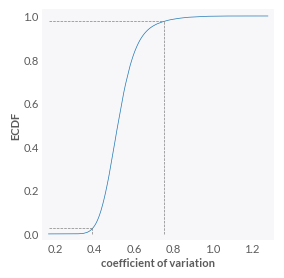

In [59]:
fig, ax = plt.subplots(figsize=(3, 3))
x = np.sort(cv_list_smooth)
y = np.arange(1, len(cv_list_smooth)+1)/len(cv_list_smooth)

x1, x2 = np.percentile(cv_list_smooth, [2.5, 97.5])
y1 = y[next(i for i,v in enumerate(x) if v > x1)]
y2 = y[next(i for i,v in enumerate(x) if v > x2)]
                       

ax.plot(np.sort(cv_list_smooth), np.arange(1, len(cv_list_smooth)+1)/len(cv_list_smooth))
ax.plot([x1, x1], [0, y1], '--', color="gray")
ax.plot([np.min(x), x1], [y1, y1], '--', color="gray")

ax.plot([x2, x2], [0, y2], '--', color="gray")
ax.plot([np.min(x), x2], [y2, y2], '--', color="gray")

ax.set_ylabel("ECDF")
ax.set_xlabel("coefficient of variation")


fig.savefig("files/cv_shuffle_data.pdf")